In [210]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.e import Model_e
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc
from neurolib.models import jacobian_aln as jac_aln
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [436]:
a = Model_e()
dur_pre = 0.
dur_post = 0.

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

max_it = 1
tol = 1e-30
incl_step = int(1. + a.params.duration/a.params.dt)
test_step = 1e-12

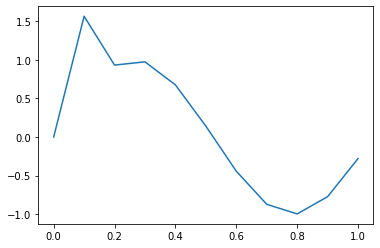

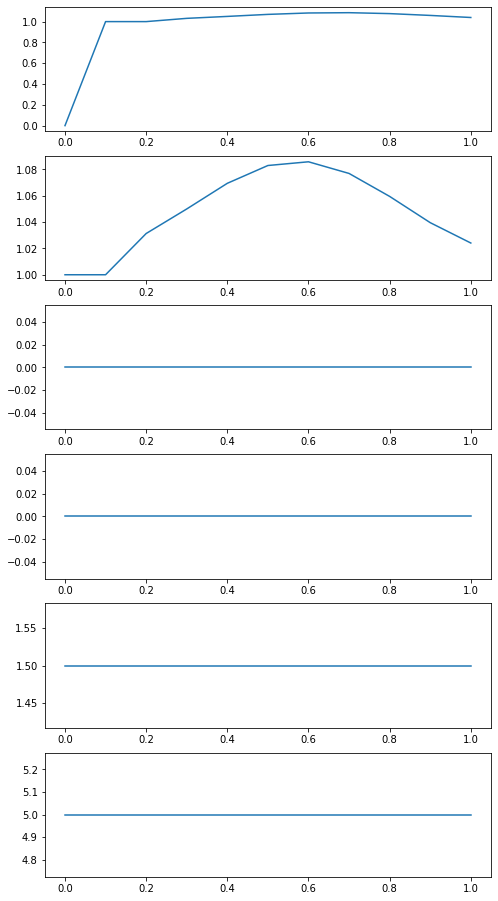

In [535]:
dur = 1.

a.params.duration = dur

target = a.getZeroTarget()
control1 = a.getZeroControl()
a.params.ext_exc_current = 0.

a.run(control=control1)

control1[0,0,1] += 1.
control1[0,0,:] += np.sin(6.*np.arange(0,dur+a.params.dt,a.params.dt))

a.run(control=control1)
plt.plot(a.t, control1[0,0,:])

target[:,0,:] = a.rates_exc[:,:]

fig, axes = plt.subplots(6, figsize=(8, 16))
axes[0].plot(a.t, a.state["rates_exc"][0,:])
axes[1].plot(a.t, a.state["mufe"][0,:])
axes[2].plot(a.t, a.state["seem"][0,:])
axes[3].plot(a.t, a.state["seev"][0,:])
axes[4].plot(a.t, a.state["sigmae_f"][0,:])
axes[5].plot(a.t, a.state["tau_exc"][0,:])

In [540]:
max_cntrl = 10. * 5.
start_step = 16
cost_params = [1.0, 2.0, 0.0]

init_state_vars = np.array( [a.params.rates_exc_init, a.params.mufe_init, a.params.seem_init, a.params.seev_init] )
cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = a.getZeroControl()
control2 += 1.

max_it = 100

A1_bestControlA, A1_bestStateA, A1_costA, runtime = a.A1(control2, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

#0.7262797905237487

set cost params
RUN  0 , total integrated cost =  1.1017987659727977
RUN  1 , total integrated cost =  0.001678545081028003
RUN  2 , total integrated cost =  0.0016654622334095598
RUN  3 , total integrated cost =  0.0016654620464392643
RUN  4 , total integrated cost =  0.0016654620464392597
RUN  5 , total integrated cost =  0.0016654620464392291
RUN  6 , total integrated cost =  0.0016654620464391914
RUN  7 , total integrated cost =  0.0016654620464391626
RUN  8 , total integrated cost =  0.0016654620464391515
RUN  9 , total integrated cost =  0.0016654620464391487
RUN  10 , total integrated cost =  0.0016654620464391307
RUN  11 , total integrated cost =  0.0016654620464391272
RUN  12 , total integrated cost =  0.0016654620464391086
RUN  13 , total integrated cost =  0.0016654620464390982
RUN  14 , total integrated cost =  0.0016654620464390405
RUN  15 , total integrated cost =  0.0016654620464390344
RUN  16 , total integrated cost =  0.0016654620464390134
RUN  17 , total integrated co

[[[ 4.91656554e-03  4.91764471e-03  4.60676554e-03  4.11038042e-03
    3.42002377e-03  2.59523364e-03  1.74271632e-03  9.79032500e-04
    3.89841033e-04 -6.15671230e-08 -6.15671230e-08]]]


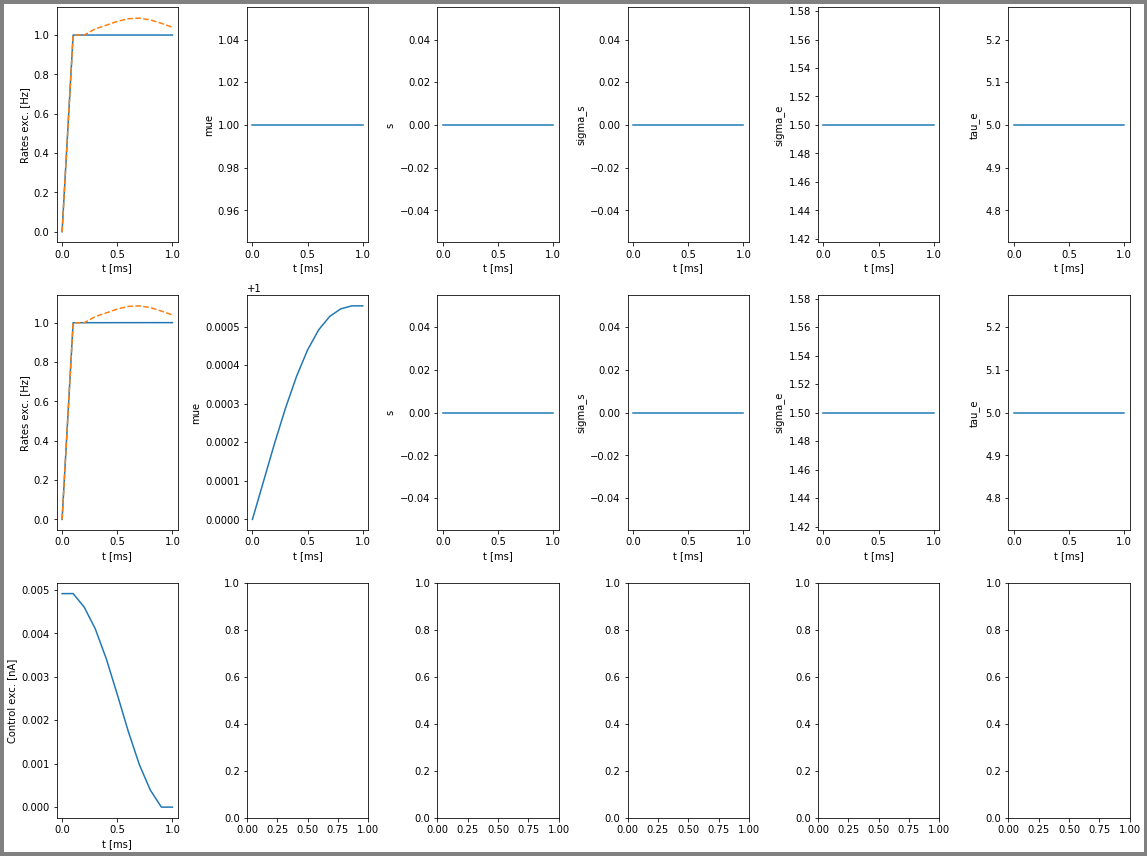

In [537]:
#0.05449064953697066
print(A1_bestControlA)
plotFunc.plot_control(a, A1_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'simp')

In [542]:
control3 = control2.copy()
control3[:,:,0] = A1_bestControlA[:,:,0]
control3[:,:,-1] = A1_bestControlA[:,:,-1]

max_it = 40

A2_bestControlA, A2_bestStateA, A2_costA, A2_runtimeA = a.A2(control3, target, max_iteration_ = max_it,
        tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

start ind =  1
RUN  0 , total integrated cost:  0.9011737751868741
RUN  1 , total integrated cost:  0.0016735428787223198
RUN  2 , total integrated cost:  0.0016654620932967023
change helped, counter =  1
RUN  3 , total integrated cost:  0.0016654620464391582
change helped, counter =  3
RUN  4 , total integrated cost:  0.0016654620464391524
RUN  5 , total integrated cost:  0.0016654620464391517
Control only changes marginally.
RUN  6 , total integrated cost:  0.0016654620464391517
Improved over  6  iterations by  100  percent.


[[[ 4.91677039e-03  4.91771134e-03  4.60677072e-03  4.11031631e-03
    3.41994241e-03  2.59513796e-03  1.74262759e-03  9.78976317e-04
    3.89833219e-04 -3.28942273e-10  2.64568401e-10]]]


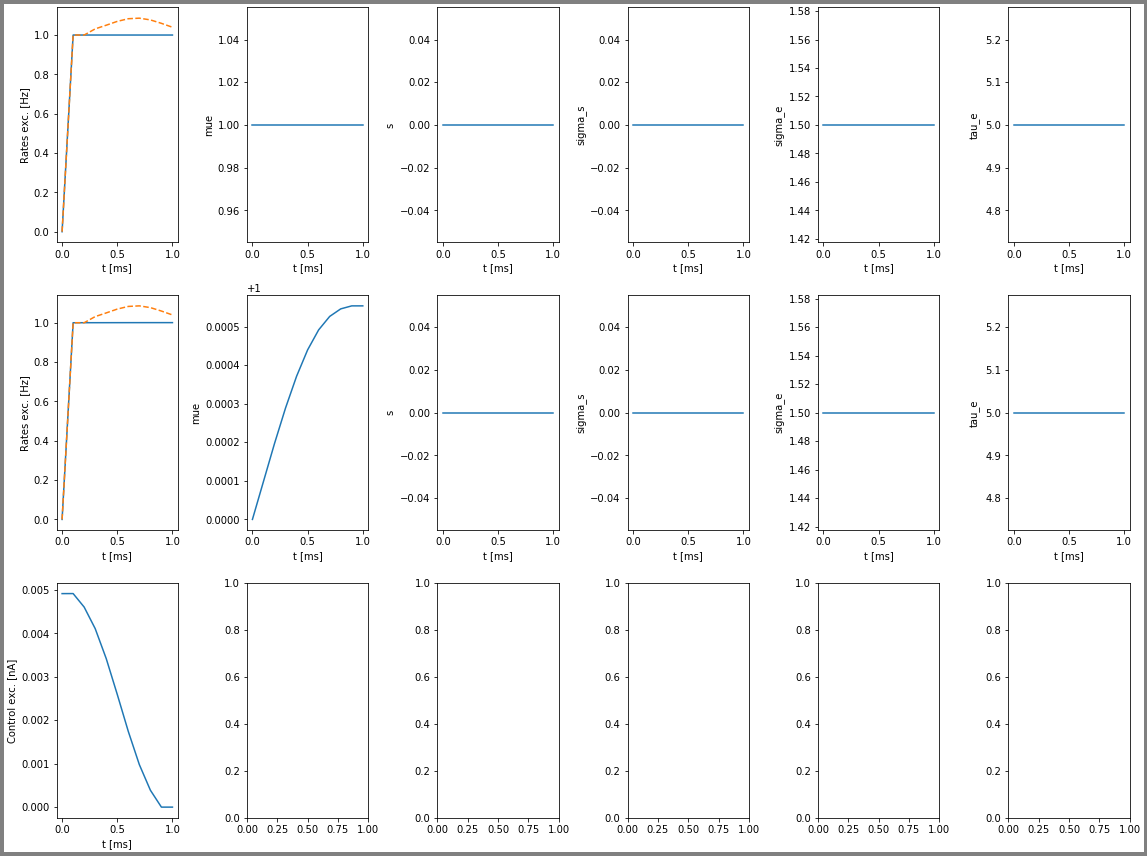

In [543]:
# 0.008474847806487532
print(A2_bestControlA)
plotFunc.plot_control(a, A2_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'a2simp')

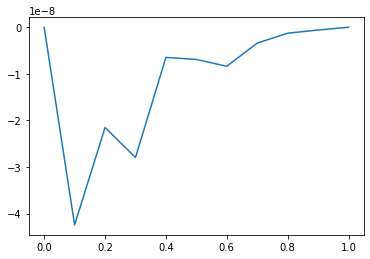

In [544]:
diff = A2_bestControlA[0,0,:] - A1_bestControlA[0,0,:]

plt.plot(a.t, diff)
plt.show()

In [274]:
def getindex(lower, upper, length, x_):
    return int( (x_ - lower) * (length-1) / (upper - lower) )

def get_value(lower, upper, length, index_):
    return lower + index_ * (upper - lower) / (length-1)

In [323]:
gradient_r = np.zeros(( len(a.params.Irange), len(a.params.sigmarange), 2 ))

sigma = a.params.sigmarange[0]
mu = a.params.Irange[0]

for sigma in range(len(a.params.sigmarange)-3):
    for mu in range(len(a.params.Irange)-1):
        res0 = jac_aln.der_mu(a, a.params.sigmarange[sigma], a.params.Irange[mu], 0, a.params.precalc_r)
        res1 = jac_aln.der_sigma(a, a.params.sigmarange[sigma], a.params.Irange[mu], 0, a.params.precalc_r)
        gradient_r[mu, sigma, 0] = res0
        gradient_r[mu, sigma, 1] = res1

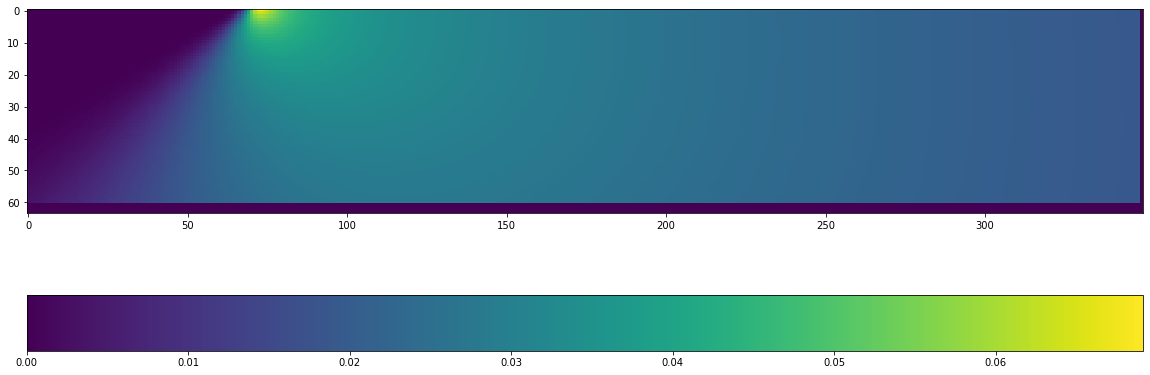

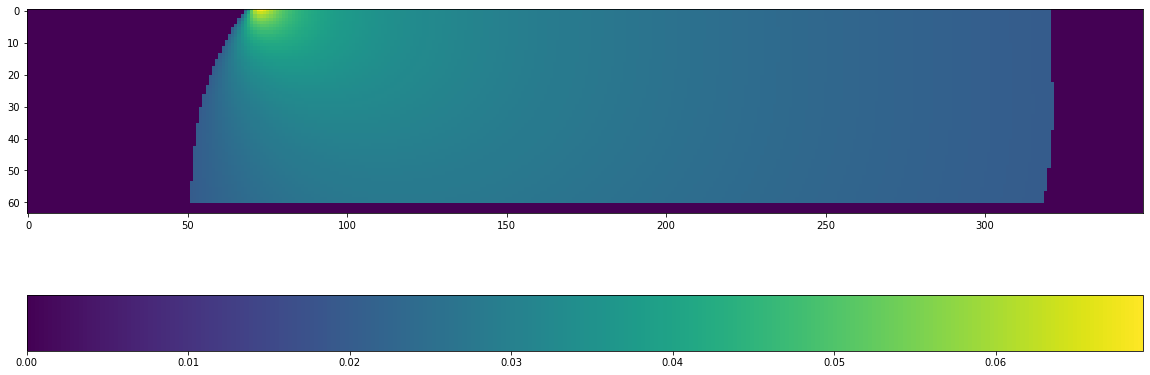

In [307]:
# gradient wrt mu

plt.figure(figsize=(20,10))
plt.imshow(gradient_r[:,:,0].T)
plt.colorbar(orientation="horizontal")
plt.show()

threshold = 0.02
large_g = gradient_r.copy()
large_g[large_g < threshold] = 0

plt.figure(figsize=(20,10))
plt.imshow(large_g[:,:,0].T)
plt.colorbar(orientation="horizontal")
plt.show()

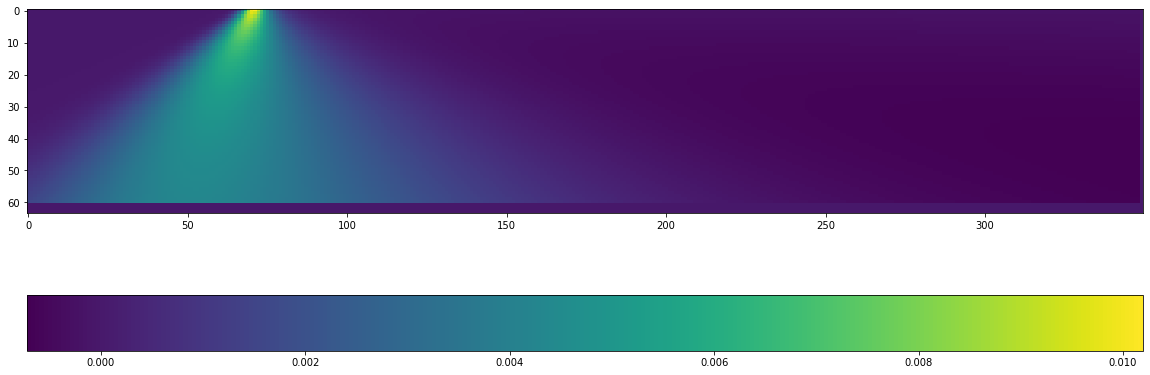

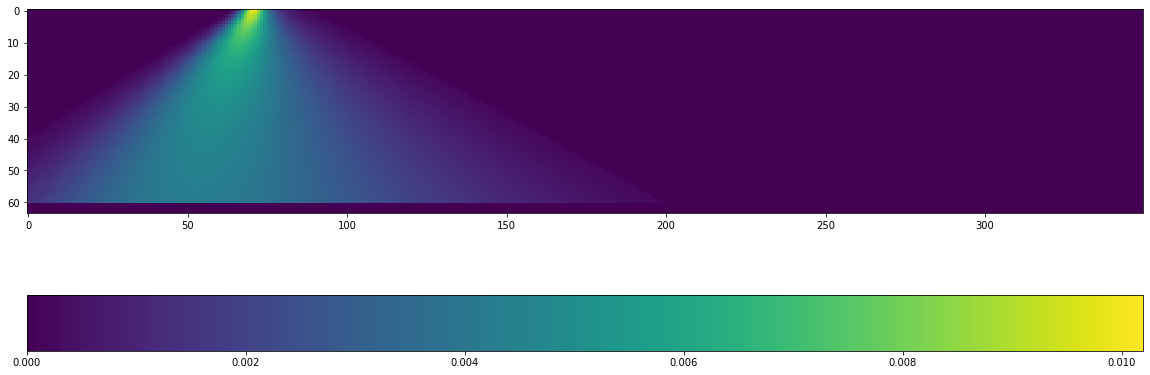

In [270]:
# gradient wrt sigma

plt.figure(figsize=(20,10))
plt.imshow(gradient_r[:,:,1].T)
plt.colorbar(orientation="horizontal")
plt.show()

threshold = 0.0002
large_g_sigma = gradient_r.copy()
large_g_sigma[large_g_sigma < threshold] = 0

plt.figure(figsize=(20,10))
plt.imshow(large_g_sigma[:,:,1].T)
plt.colorbar(orientation="horizontal")
plt.show()

In [122]:
gradient_tau = np.zeros(( len(a.params.Irange), len(a.params.sigmarange), 2 ))

sigma = a.params.sigmarange[0]
mu = a.params.Irange[0]

for sigma in range(len(a.params.sigmarange)-3):
    for mu in range(len(a.params.Irange)-1):
        res0 = jac_aln.der_mu(a, a.params.sigmarange[sigma], a.params.Irange[mu], 0, a.params.precalc_tau_mu)
        res1 = jac_aln.der_sigma(a, a.params.sigmarange[sigma], a.params.Irange[mu], 0, a.params.precalc_tau_mu)
        gradient_tau[mu, sigma, 0] = res0
        gradient_tau[mu, sigma, 1] = res1

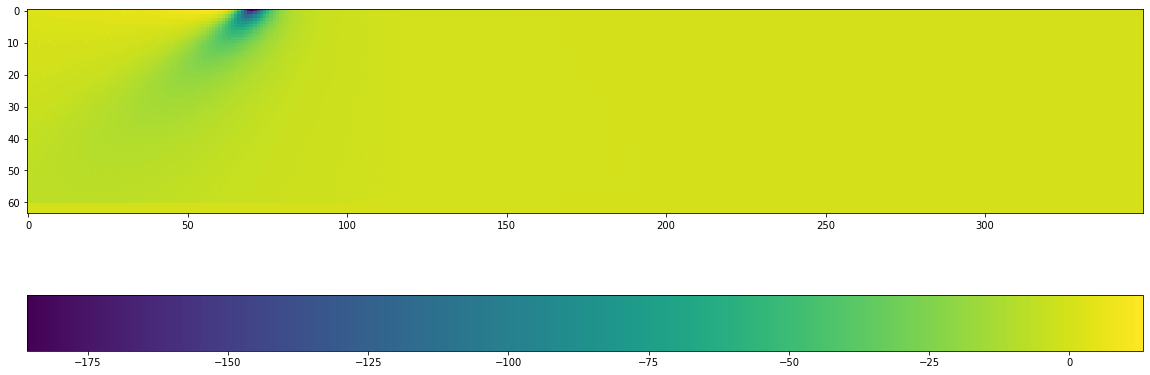

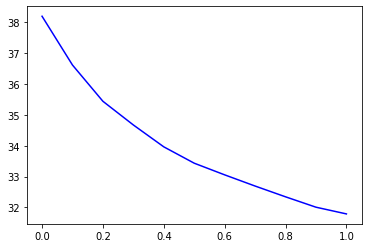

[38.19982642 36.61728213 35.44143969 34.67350651 33.96380788 33.43360313
 33.05546137 32.69242294 32.34315578 32.00645761 31.78843922]
[-4.3625  -2.6175  -1.745   -1.30875 -1.30875 -0.8725  -0.8725  -0.8725
 -0.8725  -0.43625 -0.43625]


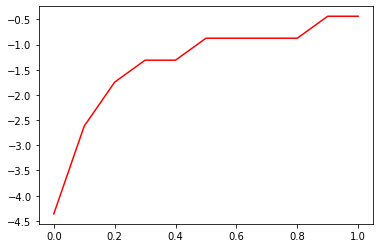

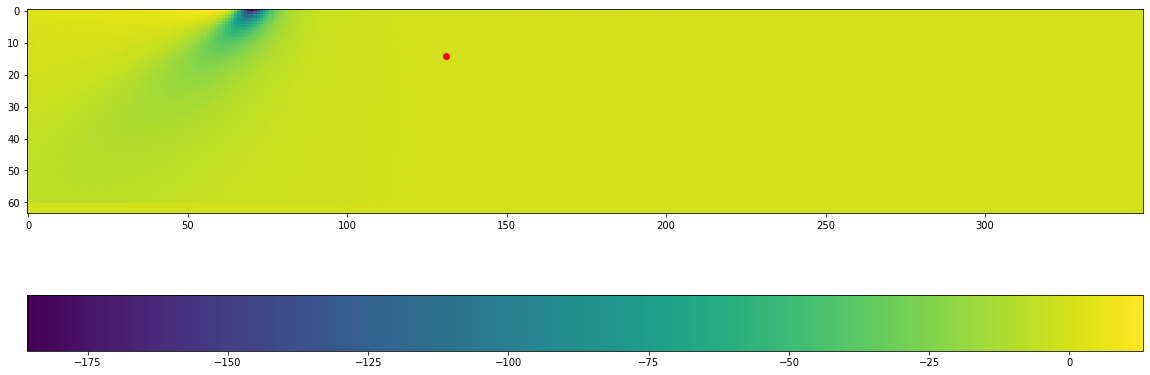

In [325]:
plt.figure(figsize=(20,10))
plt.imshow(gradient_tau[:,:,0].T)
plt.colorbar(orientation="horizontal")
plt.show()

grad_r = np.zeros(( len(a.state["mufe"][0,:]) ))
grad_tau = np.zeros(( len(a.state["mufe"][0,:]) ))
for m in range(len(a.state["mufe"][0,:])):
    index_ = getindex(a.params.Irange[0], a.params.Irange[-1], len(a.params.Irange), a.state["mufe"][0,m])
    index_sigma_ = getindex(a.params.sigmarange[0], a.params.sigmarange[-1], len(a.params.sigmarange), 1.5)
    grad_r[m] = gradient_r[index_, index_sigma_, 0]
    grad_tau[m] = gradient_tau[index_, index_sigma_, 0]
    
plt.plot(a.t, grad_r*1e3, c="blue")
plt.show()
print(grad_r*1e3)
print(grad_tau)
plt.plot(a.t, grad_tau, c="red")
plt.show()


threshold = 0.02
large_g = gradient_tau.copy()
large_g[np.abs(large_g) < threshold] = 0

plt.figure(figsize=(20,10))
plt.imshow(large_g[:,:,0].T)
plt.plot(index_, index_sigma_, "o", c="red")
plt.colorbar(orientation="horizontal")
plt.show()

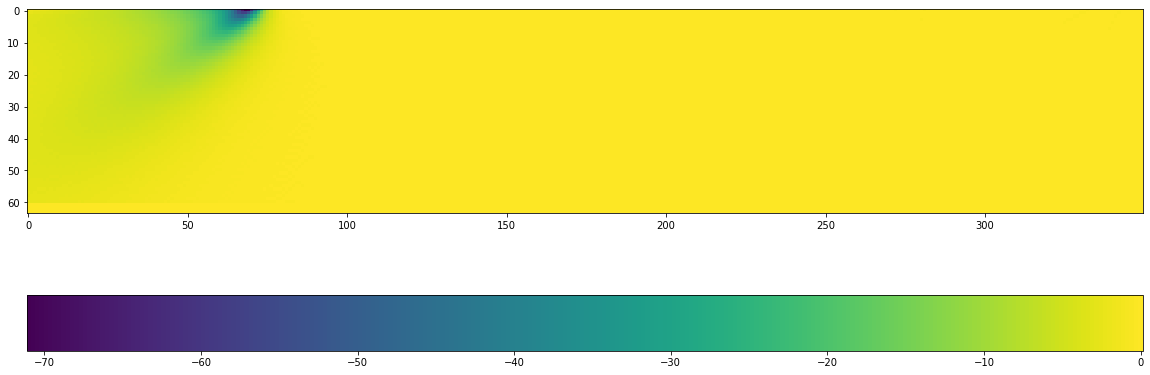

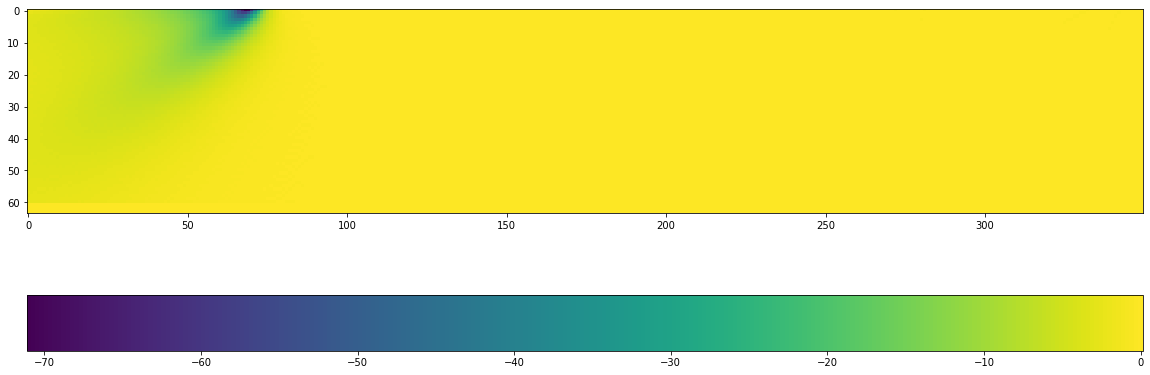

In [272]:
# gradient wrt sigma

plt.figure(figsize=(20,10))
plt.imshow(gradient_tau[:,:,1].T)
plt.colorbar(orientation="horizontal")
plt.show()

threshold = 0.0002
large_g_sigma = gradient_tau.copy()
large_g_sigma[np.abs(large_g_sigma) < threshold] = 0

plt.figure(figsize=(20,10))
plt.imshow(large_g_sigma[:,:,1].T)
plt.colorbar(orientation="horizontal")
plt.show()